### XGBoost

Como segundo modelo de clasificación se seleccionó XGBoost (Extreme Gradient Boosting), uno de los algoritmos de aprendizaje supervisado más utilizados debido a su alta capacidad predictiva y su eficiencia computacional. Este modelo construye un conjunto de árboles de decisión de manera secuencial, donde cada nuevo árbol busca corregir los errores cometidos por los anteriores, permitiendo capturar patrones complejos en los datos.

En este proyecto, XGBoost se aplicó sobre las características geométricas y de color extraídas de las imágenes, como área, relación de aspecto y estadísticas del espacio HSV. Su capacidad para modelar relaciones no lineales entre variables, junto con su robustez frente a ruido y características de distinta importancia, lo convierte en una alternativa adecuada para la clasificación de la calidad de frutas. Además, permite analizar la relevancia de cada característica en la toma de decisiones del modelo, aportando interpretabilidad al proceso de clasificación.


### Librerías

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                            cohen_kappa_score, matthews_corrcoef, 
                            confusion_matrix, classification_report,
                            balanced_accuracy_score, roc_auc_score,
                            roc_curve, average_precision_score)
from sklearn.preprocessing import label_binarize, LabelEncoder
import xgboost as xgb
from sklearn.utils.class_weight import compute_class_weight
import joblib
import json

models_dir = Path("..") / "models"
models_dir.mkdir(exist_ok=True)
xgb_quality_path = models_dir / 'xgb_quality.pkl'
xgb_size_path = models_dir / 'xgb_size.pkl'

COLOR_PRIMARY = '#FF5E8A'
COLOR_SECONDARY = '#FF8FAB'
COLOR_TERTIARY = '#FFB7C9'
COLOR_DARK = '#D43F6B'
COLOR_LIGHT = '#FFE4EC'

sns.set_style("whitegrid")
sns.set_palette([COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY, COLOR_DARK])
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [34]:
BASE_DIR = Path("..") / "data"
ANNOTATIONS_DIR = BASE_DIR / "annotations"
OUTPUT_CSV = ANNOTATIONS_DIR / "preprocessed_metadata.csv"

df = pd.read_csv(OUTPUT_CSV)
print(f"Total de muestras: {len(df)}")
print(f"Columnas disponibles: {df.columns.tolist()[:15]}...")

feature_cols = [
    'area_px', 'aspect_ratio', 'coverage_ratio',
    'hue_mean', 'saturation_mean', 'value_mean',
    'hue_std', 'saturation_std', 'value_std'
]

available_features = [col for col in feature_cols if col in df.columns]
feature_cols = available_features
print(f"Características a usar ({len(feature_cols)}): {feature_cols}")

Total de muestras: 36848
Columnas disponibles: ['original_image', 'quality', 'fruit', 'crop_path', 'x', 'y', 'width_px', 'height_px', 'area_px', 'aspect_ratio', 'num_fruits_in_image', 'relative_size_in_image', 'coverage_ratio', 'img_width', 'img_height']...
Características a usar (9): ['area_px', 'aspect_ratio', 'coverage_ratio', 'hue_mean', 'saturation_mean', 'value_mean', 'hue_std', 'saturation_std', 'value_std']


### Entrenamiento del modelo

In [30]:
X = df[feature_cols].fillna(0)
y_quality = df['quality']
y_size = df['size_category']

le_quality = LabelEncoder()
le_size = LabelEncoder()

y_quality_encoded = le_quality.fit_transform(y_quality)
y_size_encoded = le_size.fit_transform(y_size)

print(f"Clases calidad: {dict(zip(le_quality.classes_, range(len(le_quality.classes_))))}")
print(f"Clases tamaño: {dict(zip(le_size.classes_, range(len(le_size.classes_))))}")

# División de datos
X_train, X_test, y_quality_train, y_quality_test, y_size_train, y_size_test = train_test_split(
    X, y_quality_encoded, y_size_encoded, test_size=0.2, random_state=42, 
    stratify=y_quality_encoded
)

print(f"Entrenamiento: {len(X_train)} muestras")
print(f"Prueba: {len(X_test)} muestras")
print(f"\nCaracterísticas: {X_train.shape[1]}")


Clases calidad: {'bad': 0, 'good': 1, 'regular': 2}
Clases tamaño: {'grande': 0, 'mediano': 1, 'pequeño': 2}
Entrenamiento: 29478 muestras
Prueba: 7370 muestras

Características: 9


Antes de optimizar los hiperparámetros, se realizó una evaluación inicial de XGBoost utilizando validación cruzada estratificada de 5 particiones. Este procedimiento permite estimar de forma confiable la capacidad de generalización del modelo, asegurando que cada partición conserve la misma distribución de clases presente en el conjunto de datos original.

In [16]:
# Validación cruzada con XGBoost base
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_base = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

print("VALIDACIÓN CRUZADA INICIAL (parámetros por defecto)")
cv_scores_quality = cross_val_score(xgb_base, X_train, y_quality_train, cv=cv, scoring='f1_macro')
cv_scores_size = cross_val_score(xgb_base, X_train, y_size_train, cv=cv, scoring='f1_macro')

print(f"Calidad - F1-Macro CV: {cv_scores_quality.mean():.4f} (+/- {cv_scores_quality.std()*2:.4f})")
print(f"Tamaño - F1-Macro CV: {cv_scores_size.mean():.4f} (+/- {cv_scores_size.std()*2:.4f})")

VALIDACIÓN CRUZADA INICIAL (parámetros por defecto)
Calidad - F1-Macro CV: 0.9363 (+/- 0.0059)
Tamaño - F1-Macro CV: 0.9773 (+/- 0.0043)


Para medir el desempeño se utilizó la métrica **F1-Macro**, ya que evalúa de manera equilibrada todas las categorías, independientemente de su frecuencia. En cada iteración, el modelo fue entrenado con el 80% de los datos y validado con el 20% restante, repitiendo el proceso cinco veces y promediando los resultados obtenidos.

Los resultados muestran un desempeño muy sólido incluso utilizando la configuración por defecto del algoritmo con un F1-Macro para calidad de **0.9363** (± 0.0059), y para tamaño de **0.9773** (± 0.0043). Estos valores indican que XGBoost captura de manera efectiva los patrones presentes en las características extraídas de las imágenes, superando los resultados obtenidos previamente con SVM y estableciendo una base sólida para la posterior optimización de hiperparámetros.


Con el objetivo de mejorar el desempeño del modelo, se realizó una búsqueda de hiperparámetros mediante **RandomizedSearchCV**. Esta estrategia permitió explorar distintas configuraciones de XGBoost de forma eficiente, evaluando únicamente una muestra representativa del espacio de búsqueda en lugar de probar todas las combinaciones posibles, reduciendo considerablemente el costo computacional.


In [17]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

print("BÚSQUEDA DE HIPERPARÁMETROS")
print(f"Total combinaciones posibles: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['subsample']) * len(param_grid['colsample_bytree']) * len(param_grid['min_child_weight'])}")
print("Usando RandomizedSearchCV para eficiencia...")

print("\nOptimizando XGBoost para calidad...")

random_search_quality = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_distributions=param_grid,
    n_iter=9,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_quality.fit(X_train, y_quality_train)

print(f"\nMejores parámetros para CALIDAD:")
for key, value in random_search_quality.best_params_.items():
    print(f"   {key}: {value}")
print(f"   Mejor F1-Macro CV: {random_search_quality.best_score_:.4f}")

print("\nOptimizando XGBoost para TAMAÑO...")

random_search_size = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_distributions=param_grid,
    n_iter=9,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_size.fit(X_train, y_size_train)

print(f"\nMejores parámetros para tamaño:")
for key, value in random_search_size.best_params_.items():
    print(f"   {key}: {value}")
print(f"   Mejor F1-Macro CV: {random_search_size.best_score_:.4f}")


BÚSQUEDA DE HIPERPARÁMETROS
Total combinaciones posibles: 1296
Usando RandomizedSearchCV para eficiencia...

Optimizando XGBoost para calidad...
Fitting 5 folds for each of 9 candidates, totalling 45 fits



Mejores parámetros para CALIDAD:
   subsample: 0.8
   n_estimators: 300
   min_child_weight: 5
   max_depth: 9
   learning_rate: 0.3
   colsample_bytree: 1.0
   Mejor F1-Macro CV: 0.9467

Optimizando XGBoost para TAMAÑO...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Mejores parámetros para tamaño:
   subsample: 1.0
   n_estimators: 200
   min_child_weight: 5
   max_depth: 9
   learning_rate: 0.3
   colsample_bytree: 0.8
   Mejor F1-Macro CV: 0.9807


Los resultados muestran que, tanto para la clasificación de calidad como para la clasificación de tamaño, el modelo obtuvo su mejor desempeño utilizando árboles relativamente profundos y configuraciones capaces de capturar relaciones complejas entre las características geométricas y cromáticas extraídas de las imágenes. Al mismo tiempo, los parámetros de regularización seleccionados ayudaron a controlar el riesgo de sobreajuste y favorecieron una buena capacidad de generalización.

Tras la optimización, el modelo alcanzó los siguientes resultados en validación cruzada:

* **Calidad:** F1-Macro = **0.9467**
* **Tamaño:** F1-Macro = **0.9807**

Estos resultados superan los obtenidos previamente con SVM, especialmente en la tarea de calidad, lo que sugiere que XGBoost aprovecha mejor las relaciones no lineales presentes en los datos. En consecuencia, los hiperparámetros encontrados fueron seleccionados para entrenar los modelos finales y realizar la evaluación sobre el conjunto de prueba independiente.

Durante el entrenamiento de los modelos finales de XGBoost se incorporó un mecanismo para compensar posibles desbalances en las categorías de calidad y tamaño. Aunque el dataset presenta una distribución relativamente equilibrada, algunas clases contienen menos ejemplos que otras, lo que puede llevar al modelo a favorecer las categorías más frecuentes.

Para mitigar este problema, se calcularon pesos de clase de forma automática utilizando la distribución real de los datos de entrenamiento. De esta manera, los errores cometidos sobre clases menos representadas reciben una penalización mayor durante el proceso de aprendizaje, obligando al modelo a prestar atención a todas las categorías y no únicamente a las más abundantes.

In [19]:
if xgb_quality_path.exists() and xgb_size_path.exists():
    print("Cargando modelos XGBoost guardados...")
    best_xgb_quality = joblib.load(xgb_quality_path)
    best_xgb_size = joblib.load(xgb_size_path)
    
    y_quality_pred = best_xgb_quality.predict(X_test)
    y_quality_proba = best_xgb_quality.predict_proba(X_test)
    y_size_pred = best_xgb_size.predict(X_test)
    y_size_proba = best_xgb_size.predict_proba(X_test)
    
    print("Predicciones generadas desde modelos cargados")
    
else:
    print("No se encontraron modelos guardados. Entrenando desde cero...")
    
    # Entrenar modelo óptimo para calidad
    best_xgb_quality = xgb.XGBClassifier(
        **random_search_quality.best_params_,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        scale_pos_weight=None
    )
    class_weights_quality = compute_class_weight('balanced', classes=np.unique(y_quality_train), y=y_quality_train)
    weight_dict_quality = dict(zip(np.unique(y_quality_train), class_weights_quality))
    print(f"Pesos por clase (Calidad): {weight_dict_quality}")
    
    # Entrenar
    best_xgb_quality.fit(X_train, y_quality_train)
    
    # Entrenar modelo óptimo para tamaño
    class_weights_size = compute_class_weight('balanced', classes=np.unique(y_size_train), y=y_size_train)
    weight_dict_size = dict(zip(np.unique(y_size_train), class_weights_size))
    print(f"Pesos por clase (Tamaño): {weight_dict_size}")
    
    best_xgb_size = xgb.XGBClassifier(
        **random_search_size.best_params_,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    best_xgb_size.fit(X_train, y_size_train)
    
    # Predicciones
    y_quality_pred = best_xgb_quality.predict(X_test)
    y_quality_proba = best_xgb_quality.predict_proba(X_test)
    y_size_pred = best_xgb_size.predict(X_test)
    y_size_proba = best_xgb_size.predict_proba(X_test)
    
    # Guardar modelos entrenados
    joblib.dump(best_xgb_quality, xgb_quality_path)
    joblib.dump(best_xgb_size, xgb_size_path)
    
    print("Modelos entrenados, predicciones generadas y guardados")

No se encontraron modelos guardados. Entrenando desde cero...
Pesos por clase (Calidad): {np.int64(0): np.float64(1.0825162498622893), np.int64(1): np.float64(0.8207484129635817), np.int64(2): np.float64(1.165737335389726)}
Pesos por clase (Tamaño): {np.int64(0): np.float64(0.8464851826326671), np.int64(1): np.float64(1.0221574950587746), np.int64(2): np.float64(1.190020588591498)}
Modelos entrenados, predicciones generadas y guardados


Esta estrategia resulta especialmente importante en problemas de clasificación multiclase, ya que ayuda a mejorar el desempeño sobre las clases minoritarias y favorece métricas balanceadas como el **F1-Macro**, utilizada como criterio principal de evaluación en este proyecto.

Una vez configurados estos pesos y los hiperparámetros óptimos obtenidos durante la fase de búsqueda, los modelos fueron entrenados, evaluados sobre el conjunto de prueba y posteriormente almacenados en disco.


### Evaluación del modelo

In [31]:
def evaluate_model_full(y_true, y_pred, y_proba, model_name="Modelo", class_names=None):
    """Evaluación completa con todas las métricas"""
    
    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(y_true)))]
    
    results = {
        'modelo': model_name,
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred)
    }
    
    if y_proba is not None and len(class_names) > 2:
        y_bin = label_binarize(y_true, classes=range(len(class_names)))
        try:
            auc_macro = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
            results['auc_macro'] = auc_macro
        except:
            results['auc_macro'] = None
    
    print(f" {model_name}")
    print(f"Precision Macro:    {results['precision_macro']:.4f}")
    print(f"Recall Macro:       {results['recall_macro']:.4f}")
    print(f"F1-Score Macro:     {results['f1_macro']:.4f}")
    print(f"Precision Weighted: {results['precision_weighted']:.4f}")
    print(f"Recall Weighted:    {results['recall_weighted']:.4f}")
    print(f"F1-Score Weighted:  {results['f1_weighted']:.4f}")
    print(f"Cohen's Kappa:      {results['cohen_kappa']:.4f}")
    print(f"MCC:                {results['mcc']:.4f}")
    print(f"Balanced Accuracy:  {results['balanced_accuracy']:.4f}")
    if results.get('auc_macro'):
        print(f"AUC-ROC Macro:      {results['auc_macro']:.4f}")
    
    print(f"\nReporte por clase:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    return results

def plot_confusion_matrix_full(y_true, y_pred, class_names, title="Matriz de Confusión"):
    """Matriz de confusión con conteos y porcentajes"""
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title(f'{title} - Conteos', fontsize=12)
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Reds', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title(f'{title} - Porcentajes (%)', fontsize=12)
    axes[1].set_xlabel('Predicción')
    axes[1].set_ylabel('Real')
    
    plt.tight_layout()
    plt.show()

def plot_roc_curves(y_true, y_proba, class_names, title="Curvas ROC"):
    """Curvas ROC para cada clase"""
    y_bin = label_binarize(y_true, classes=range(len(class_names)))
    n_classes = len(class_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY, COLOR_DARK]
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        auc = roc_auc_score(y_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                label=f'{class_names[i]} (AUC = {auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'{title}', fontsize=14)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, title="Importancia de Características"):
    """Visualiza importancia de características"""
    importance = model.feature_importances_
    sorted_idx = np.argsort(importance)[::-1]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = [COLOR_PRIMARY] * len(feature_names)
    bars = ax.barh(range(len(feature_names)), importance[sorted_idx], color=colors)
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx])
    ax.set_xlabel('Importancia')
    ax.set_title(title, fontsize=14)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar importancia ordenada
    print("\nImportancia de características:")
    for i, idx in enumerate(sorted_idx[:10]):
        print(f"  {i+1}. {feature_names[idx]}: {importance[idx]:.4f}")

In [35]:
class_names_quality = ['bad', 'good', 'regular']

print("EVALUACIÓN XGBOOST - CLASIFICACIÓN DE CALIDAD")

quality_results = evaluate_model_full(
    y_quality_test, y_quality_pred, y_quality_proba,
    model_name="XGBoost - Calidad",
    class_names=class_names_quality
)

EVALUACIÓN XGBOOST - CLASIFICACIÓN DE CALIDAD
 XGBoost - Calidad
Precision Macro:    0.9493
Recall Macro:       0.9497
F1-Score Macro:     0.9494
Precision Weighted: 0.9491
Recall Weighted:    0.9484
F1-Score Weighted:  0.9487
Cohen's Kappa:      0.9218
MCC:                0.9219
Balanced Accuracy:  0.9497
AUC-ROC Macro:      0.9929

Reporte por clase:
              precision    recall  f1-score   support

         bad       0.91      0.94      0.92      2269
        good       0.96      0.94      0.95      2994
     regular       0.99      0.97      0.98      2107

    accuracy                           0.95      7370
   macro avg       0.95      0.95      0.95      7370
weighted avg       0.95      0.95      0.95      7370



Los resultados muestran un desempeño sobresaliente, alcanzando un **Accuracy del 95%** y un **F1-Score Macro de 0.9494**, superando los resultados obtenidos previamente con SVM.

- Las métricas globales indican que el modelo mantiene un comportamiento equilibrado entre todas las categorías de calidad, sin favorecer de manera significativa a ninguna clase en particular. 
- Además, los altos valores de AUC-ROC y de los coeficientes de concordancia confirman una excelente capacidad para diferenciar frutas buenas, regulares y dañadas.
- Las clases **good** y **bad** también registraron mejoras respecto al modelo SVM, especialmente en la identificación de frutas dañadas, que era uno de los principales puntos débiles observados anteriormente.

En conjunto, estos resultados demuestran que XGBoost aprovecha de forma más efectiva las relaciones complejas presentes en las características extraídas de las imágenes. Como consecuencia, se posiciona como el mejor modelo tabular evaluado en el proyecto y establece una referencia sólida para comparar posteriormente el rendimiento de la red neuronal convolucional (CNN).


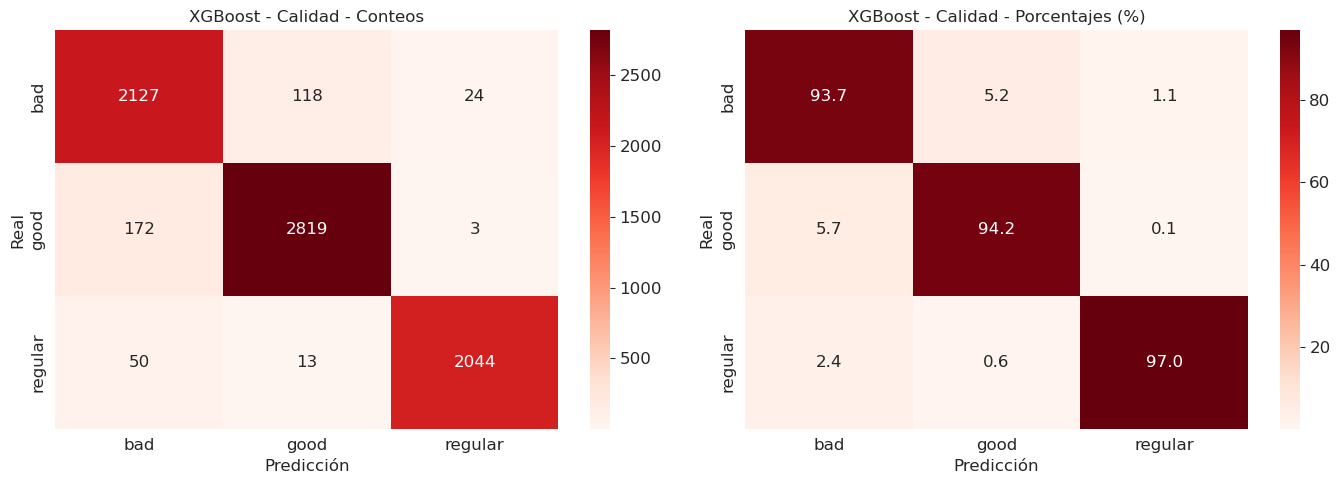

In [36]:
plot_confusion_matrix_full(y_quality_test, y_quality_pred, class_names_quality, "XGBoost - Calidad")

La matriz de confusión confirma el desempeño de XGBoost en la clasificación de calidad, mostrando una mejora consistente respecto al modelo SVM. La mayoría de las predicciones se concentran en la diagonal principal, lo que indica una alta tasa de aciertos en las tres categorías.

- La clase **regular** alcanzó el mejor resultado, con un **97% de aciertos**, seguida por las clases **good** (94.2%) y **bad** (93.7%). Estos resultados reflejan una capacidad sólida para distinguir entre los diferentes niveles de calidad de las frutas.
- El principal avance respecto a SVM se observa en la reducción de las confusiones entre las clases **good** y **bad**, que anteriormente representaban la mayor fuente de error. XGBoost logró disminuir estos errores, mostrando una mejor capacidad para interpretar combinaciones complejas de color, brillo y saturación presentes en las imágenes.

En general, la matriz de confusión evidencia que XGBoost aprovecha de manera más eficiente las características extraídas durante el preprocesamiento, alcanzando un comportamiento más estable y equilibrado entre todas las clases. Aunque persisten algunos errores entre frutas sanas y dañadas, su frecuencia es considerablemente menor que en SVM, consolidando a XGBoost como el mejor modelo tabular evaluado para esta tarea.


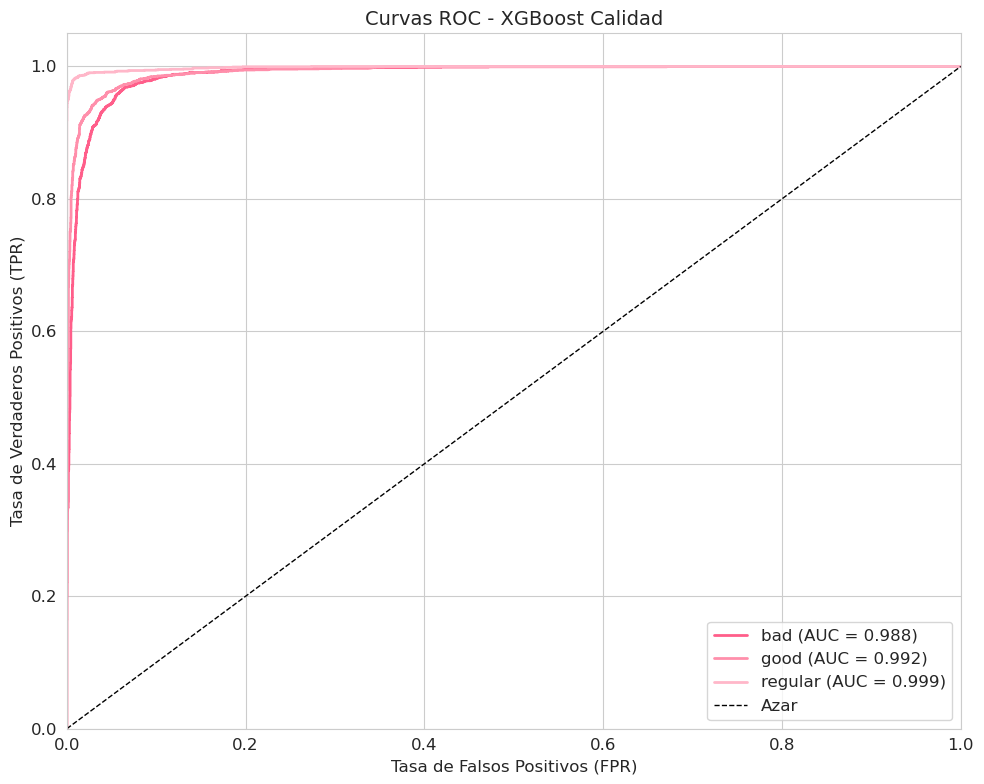

In [37]:
plot_roc_curves(y_quality_test, y_quality_proba, class_names_quality, "Curvas ROC - XGBoost Calidad")

La curva ROC muestra una excelente capacidad de discriminación para las tres clases de calidad, con valores de AUC superiores al 0.98. Esto indica que el modelo distingue correctamente entre frutas buenas, regulares y dañadas incluso cuando se modifican los umbrales de decisión.

* **Clase regular (AUC = 0.999):** Presenta una separación prácticamente perfecta respecto a las demás categorías.
* **Clase good (AUC = 0.992):** Muestra una mejora frente al SVM, reduciendo las confusiones con otras clases.
* **Clase bad (AUC = 0.988):** También mejora respecto al SVM, evidenciando una mejor identificación de frutas defectuosas.

En conjunto, estas curvas confirman que XGBoost no solo logra una alta precisión en sus predicciones, sino que también genera probabilidades confiables y bien separadas entre clases.

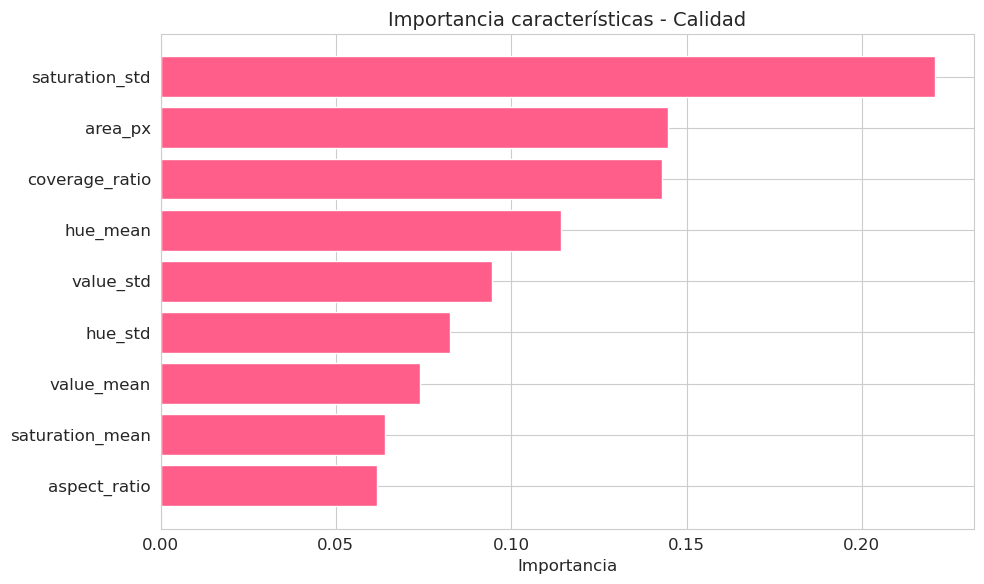


Importancia de características:
  1. saturation_std: 0.2209
  2. area_px: 0.1448
  3. coverage_ratio: 0.1431
  4. hue_mean: 0.1141
  5. value_std: 0.0946
  6. hue_std: 0.0826
  7. value_mean: 0.0741
  8. saturation_mean: 0.0641
  9. aspect_ratio: 0.0617


In [38]:
plot_feature_importance(best_xgb_quality, feature_cols, "Importancia características - Calidad")

El gráfico de importancia de características permite identificar cuáles variables tuvieron mayor influencia en las decisiones del modelo XGBoost al clasificar la calidad de las frutas.

* **saturation_std** fue la característica más importante, indicando que la variabilidad de la saturación del color es un factor clave para distinguir frutas sanas de frutas deterioradas. Esto sugiere que las manchas, zonas dañadas o cambios de color generan patrones fácilmente detectables por el modelo.

* **area_px y coverage_ratio** también tuvieron una contribución significativa. Aunque la calidad está asociada principalmente al color, estas variables muestran que ciertas características relacionadas con el tamaño o la forma del objeto aportan información adicional para la clasificación.

* **Las variables de color (`hue_mean`, `hue_std`, `value_mean` y `value_std`)** complementan el proceso de decisión, ayudando a capturar diferencias de tonalidad, brillo y maduración entre las frutas.

* **aspect_ratio** presentó la menor importancia, indicando que la relación entre ancho y alto aporta poca información para determinar la calidad del producto.

Por lo tanto, se observa que XGBoost basa sus decisiones principalmente en la variación de la saturación y en características geométricas del objeto.


In [39]:
class_names_size = ['pequeño', 'mediano', 'grande']

print("EVALUACIÓN XGBOOST - CLASIFICACIÓN DE TAMAÑO")
size_results = evaluate_model_full(
    y_size_test, y_size_pred, y_size_proba,
    model_name="XGBoost - Tamaño",
    class_names=class_names_size
)

EVALUACIÓN XGBOOST - CLASIFICACIÓN DE TAMAÑO
 XGBoost - Tamaño
Precision Macro:    0.9813
Recall Macro:       0.9814
F1-Score Macro:     0.9813
Precision Weighted: 0.9817
Recall Weighted:    0.9815
F1-Score Weighted:  0.9816
Cohen's Kappa:      0.9720
MCC:                0.9721
Balanced Accuracy:  0.9814
AUC-ROC Macro:      0.9987

Reporte por clase:
              precision    recall  f1-score   support

     pequeño       0.99      0.98      0.99      2903
     mediano       0.96      0.98      0.97      2440
      grande       0.99      0.98      0.98      2027

    accuracy                           0.98      7370
   macro avg       0.98      0.98      0.98      7370
weighted avg       0.98      0.98      0.98      7370



En general, el modelo muestra mejor desempeño, superando tanto al baseline como al SVM.

* **Rendimiento muy alto (Accuracy = 98%)**: el modelo alcanza ~98.15% de exactitud y un F1-Macro de 0.9813, lo que indica un comportamiento muy estable en las tres clases.
* **Alta consistencia (MCC y Kappa ≈ 0.97)**: estos valores confirman que las predicciones son muy confiables y no están influenciadas por sesgos importantes.
* **Separación casi perfecta (AUC = 0.9987)**: las clases `pequeño`, `mediano` y `grande` están prácticamente bien separadas en términos probabilísticos.

Tenemos que en la clasificación por clases, se muestra una clasificación casi perfecta, donde el mediano sigue siendo el más difícil, pero es mejor manejado que el SVM. XGBoost prácticamente resuelve por completo la tarea de clasificación de tamaño, alcanzando un nivel de desempeño cercano al óptimo. Esto confirma que las variables geométricas (especialmente normalized_area) son suficientes para resolver el problema sin necesidad de modelos más complejos como redes neuronales convolucionales.


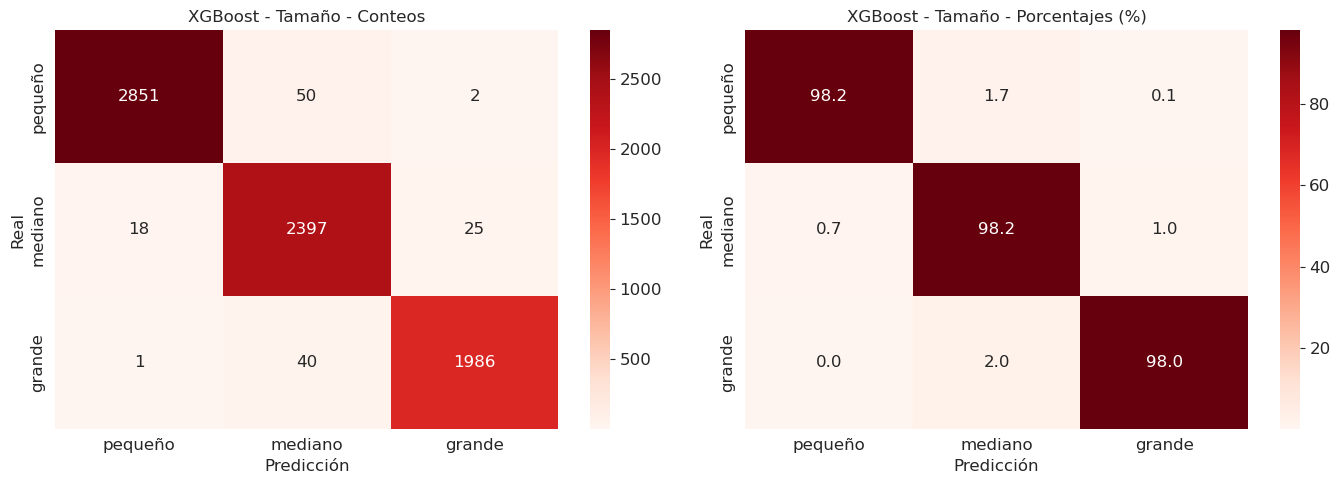

In [40]:
plot_confusion_matrix_full(y_size_test, y_size_pred, class_names_size, "XGBoost - Tamaño")

La matriz de confusión muestra que XGBoost logra un  buen desempeño en la clasificación de tamaño, con una diagonal principal superior al 98% en todas las clases. En comparación con el SVM, se observa una mejora clara tanto en precisión como en estabilidad.

- Las tres clases presentan un comportamiento muy equilibrado, con tasas de acierto cercanas al 98%. La clase mediano, que suele ser la más difícil por su posición intermedia, también mantiene un rendimiento alto, lo que indica que el modelo maneja bien los casos límite.
- Además, los errores entre clases adyacentes se reducen de forma importante respecto al SVM, y las confusiones entre extremos (pequeño vs grande) son prácticamente inexistentes. Esto sugiere que el modelo establece fronteras muy claras en el espacio de características, especialmente gracias a normalized_area.


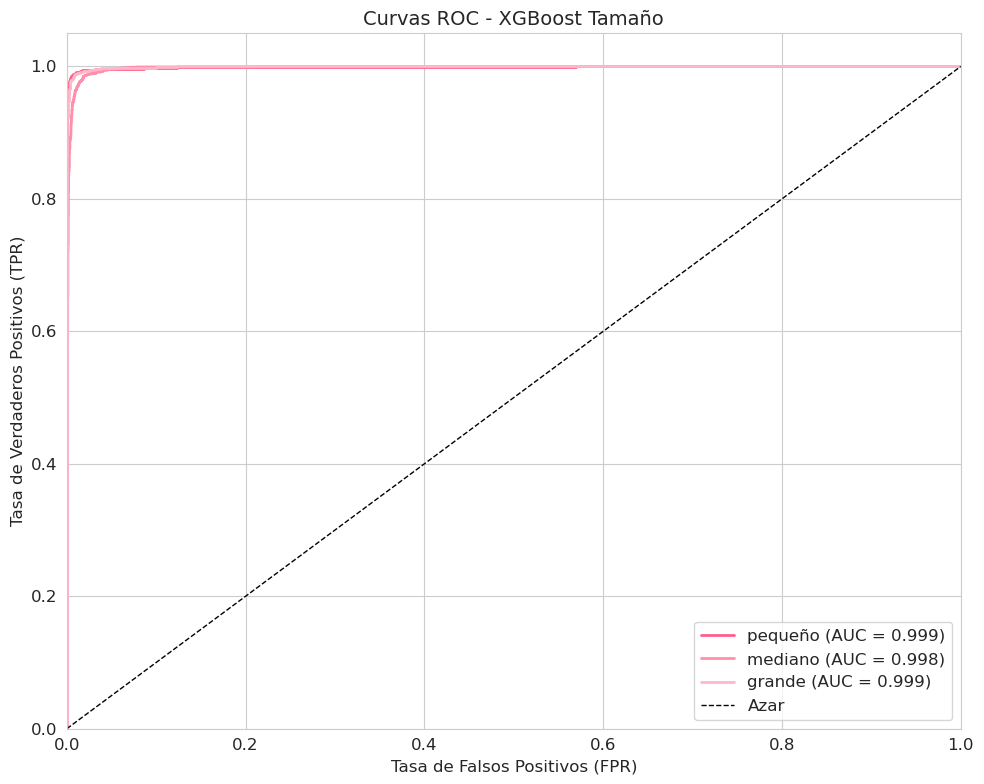

In [41]:
plot_roc_curves(y_size_test, y_size_proba, class_names_size, "Curvas ROC - XGBoost Tamaño")

En la curva ROC, todas las clases presentan valores extremadamente altos (≈ 0.998–0.999), lo que significa que el modelo distingue los tamaños con muy poca o nula ambigüedad. GBoost logra una separación casi perfecta del espacio de características para la tarea de tamaño.


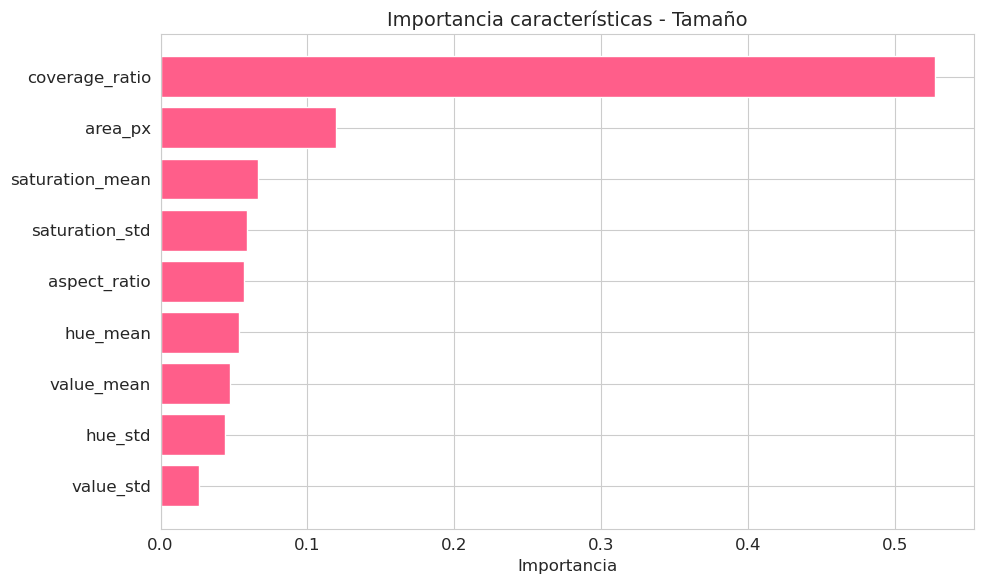


Importancia de características:
  1. coverage_ratio: 0.5276
  2. area_px: 0.1197
  3. saturation_mean: 0.0665
  4. saturation_std: 0.0587
  5. aspect_ratio: 0.0569
  6. hue_mean: 0.0535
  7. value_mean: 0.0471
  8. hue_std: 0.0436
  9. value_std: 0.0264


In [42]:
plot_feature_importance(best_xgb_size, feature_cols, "Importancia características - Tamaño")

Este gráfico muestra claramente qué variables realmente usa XGBoost para decidir el tamaño de las frutas. A diferencia de la tarea de calidad, aquí el modelo prácticamente ignora el color y se enfoca casi por completo en la geometría y la escala del objeto.

- La variable más importante por mucho es `coverage_ratio`, con más de la mitad del poder predictivo del modelo. Esto indica que el tamaño se determina principalmente por cuánto espacio ocupa la fruta dentro de la imagen. En un sistema con cámara fija, esto es lógico: frutas más grandes ocupan más píxeles de forma consistente, por lo que el modelo puede separarlas casi directamente con esta sola variable.
- La segunda variable más relevante es `area_px`, que complementa a `coverage_ratio` aportando una medida más directa del tamaño en píxeles. Aunque ambas están relacionadas, juntas refinan la decisión del modelo y ayudan a corregir pequeñas variaciones por forma, inclinación o ruido en la segmentación. En conjunto, estas dos variables explican la mayor parte del comportamiento del modelo.
- El resto de variables (saturación, matiz, brillo y aspecto) tienen una importancia mucho menor. Esto confirma que el color no es útil para distinguir tamaños, ya que una fruta grande o pequeña puede tener cualquier tonalidad dependiendo del estado de maduración. El modelo prácticamente “ignora” estas características en esta tarea.


Curva de aprendizaje - calidad


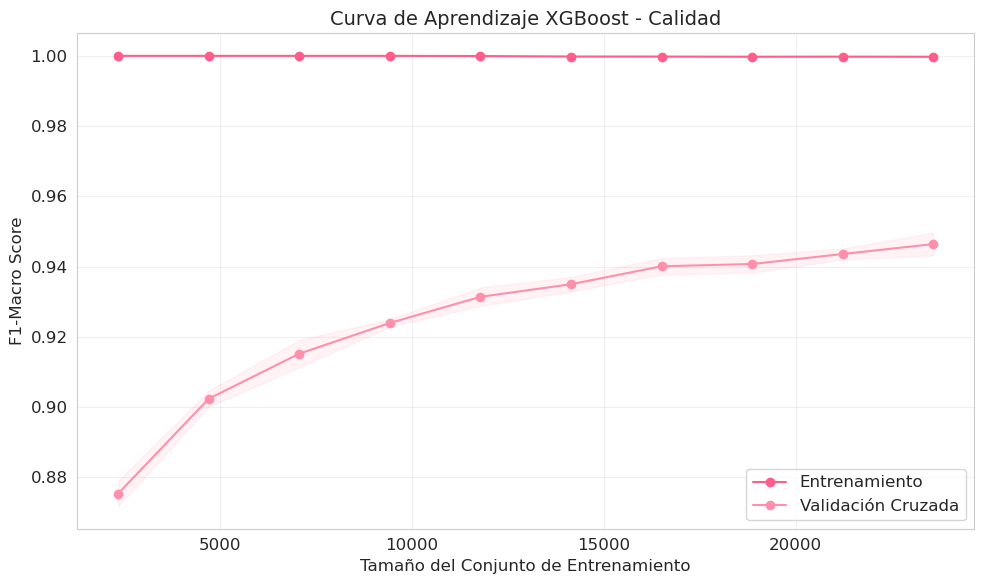

Curva de aprendizaje - tamaño


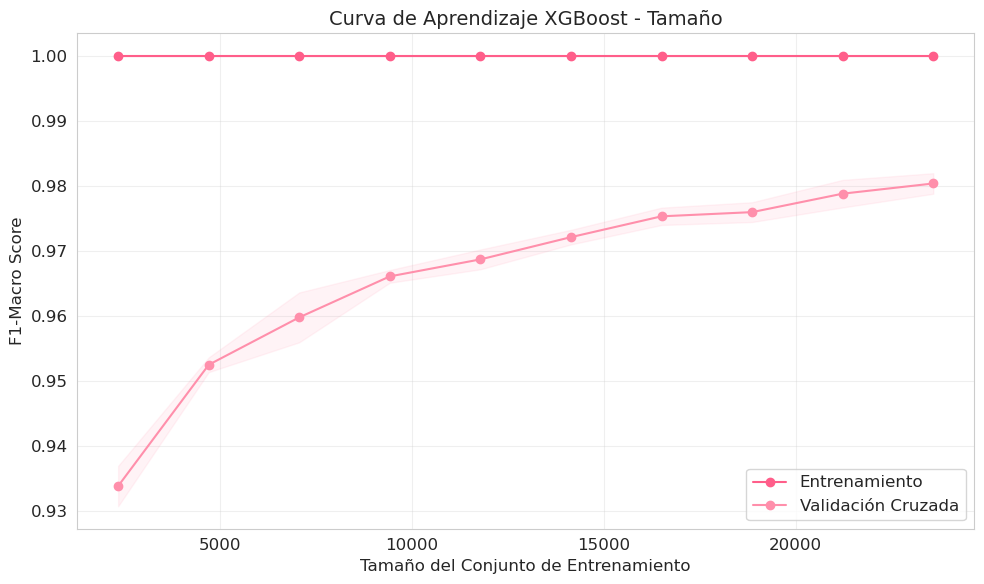

In [23]:
def plot_learning_curve(model, X, y, title="Curva de Aprendizaje"):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1_macro'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.1, color=COLOR_PRIMARY)
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                    alpha=0.1, color=COLOR_SECONDARY)
    ax.plot(train_sizes, train_mean, 'o-', color=COLOR_PRIMARY, label='Entrenamiento')
    ax.plot(train_sizes, test_mean, 'o-', color=COLOR_SECONDARY, label='Validación Cruzada')
    
    ax.set_xlabel('Tamaño del Conjunto de Entrenamiento')
    ax.set_ylabel('F1-Macro Score')
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Curva de aprendizaje - calidad")
plot_learning_curve(best_xgb_quality, X_train, y_quality_train, "Curva de Aprendizaje XGBoost - Calidad")

print("Curva de aprendizaje - tamaño")
plot_learning_curve(best_xgb_size, X_train, y_size_train, "Curva de Aprendizaje XGBoost - Tamaño")

Las curvas de aprendizaje de XGBoost para las tareas de calidad y tamaño permiten evaluar si el modelo está generalizando bien o si está limitado por los datos o por su capacidad de representación.

- En la tarea de calidad, la curva de entrenamiento se mantiene constante en 1.0 durante todo el proceso, lo que indica que el modelo tiene capacidad suficiente para memorizar completamente los datos de entrenamiento. En contraste, la curva de validación comienza alrededor de 0.875 y sube progresivamente hasta aproximadamente 0.946. Este comportamiento sugiere una brecha estable entre entrenamiento y validación. Aunque existe cierta diferencia, la curva de validación sigue subiendo al final, lo que indica que el modelo todavía podría mejorar ligeramente con más datos. En otras palabras, no hay una saturación total, pero sí un límite claro impuesto por la representación de las variables tabulares, especialmente en casos donde el color y la iluminación generan ambigüedad.
- En la clasificación de tamaño ocurre algo distinto. El entrenamiento también se mantiene en 1.0, pero la curva de validación crece de forma más rápida y estable, pasando de valores cercanos a 0.93 hasta estabilizarse alrededor de 0.98. A diferencia de la tarea de calidad, aquí la curva de validación se aplana claramente al final, lo que indica que el modelo ya alcanzó un punto de saturación. Esto significa que las variables usadas (como coverage_ratio y area_px) capturan casi toda la información útil del problema. Agregar más datos probablemente no mejoraría el rendimiento de forma significativa.

Esto justifica el diseño del sistema: el tamaño puede resolverse completamente con modelos tabulares como XGBoost, mientras que la calidad probablemente requiere un enfoque más expresivo como redes neuronales convolucionales, capaces de capturar patrones locales de textura e iluminación que los descriptores actuales no pueden representar bien.


### Conclusiones

In [43]:
def analyze_errors_detailed(y_true, y_pred, X_test_df, feature_names, class_names, title="Análisis de Errores"):
    errors = y_true != y_pred
    error_rate = errors.mean()
    
    print(f"\n{title}")
    print(f"Tasa de error: {error_rate:.4f} ({errors.sum()} muestras)")
    
    # Matriz de confusión normalizada
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    print("\nConfusiones más comunes:")
    confusion_pairs = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm_norm[i, j] > 0.05:
                confusion_pairs.append((class_names[i], class_names[j], cm_norm[i, j]))
                print(f"  {class_names[i]} → {class_names[j]}: {cm_norm[i, j]:.2%}")
    
    # Estadísticas por clase
    print("\nEstadísticas por clase:")
    for i, class_name in enumerate(class_names):
        class_mask = y_true == i
        class_errors = errors[class_mask]
        error_class_rate = class_errors.mean() if class_mask.sum() > 0 else 0
        print(f"  {class_name}: {error_class_rate:.2%} error")

X_test_df = pd.DataFrame(X_test, columns=feature_cols)

analyze_errors_detailed(y_quality_test, y_quality_pred, X_test_df, feature_cols, class_names_quality, "Errores XGBoost - Calidad")
analyze_errors_detailed(y_size_test, y_size_pred, X_test_df, feature_cols, class_names_size, "Errores XGBoost - Tamaño")



Errores XGBoost - Calidad
Tasa de error: 0.0516 (380 muestras)

Confusiones más comunes:
  bad → good: 5.20%
  good → bad: 5.74%

Estadísticas por clase:
  bad: 6.26% error
  good: 5.85% error
  regular: 2.99% error

Errores XGBoost - Tamaño
Tasa de error: 0.0185 (136 muestras)

Confusiones más comunes:

Estadísticas por clase:
  pequeño: 1.79% error
  mediano: 1.76% error
  grande: 2.02% error


El modelo presenta una tasa de error de aproximadamente 5.16%, lo que equivale a 380 muestras mal clasificadas. Lo más importante no es el número total, sino cómo se distribuyen esos errores. La mayoría de fallos ocurre entre las clases `good` y `bad`. En concreto, algunas frutas sanas son clasificadas como defectuosas y viceversa. Esto es crítico a nivel práctico, ya que implica tanto desperdicio de producto como posibles fallos en el control de calidad.

En la clasificación de tamaño, como ya sabemos, el error es mucho menor, alrededor de 1.85% (136 muestras). Además, estos errores están distribuidos de forma bastante uniforme entre las tres clases, sin un patrón claro de confusión dominante. Esto sugiere que los errores aquí no provienen de un problema conceptual del modelo, sino de ruido en los datos, como variaciones en la posición de la fruta, inclinación, o pequeñas diferencias en la segmentación de la imagen. En general, el modelo no muestra sesgos importantes en esta tarea.

En tamaño, el modelo ya es suficientemente robusto para un entorno real, ya que el error es bajo y aleatorio. En cambio, en calidad, el problema es más difícil porque los errores están concentrados en confusiones entre clases críticas


In [26]:
models_dir = Path("..") / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(best_xgb_quality, models_dir / 'xgb_quality.pkl')
joblib.dump(best_xgb_size, models_dir / 'xgb_size.pkl')
joblib.dump(le_quality, models_dir / 'label_encoder_quality.pkl')
joblib.dump(le_size, models_dir / 'label_encoder_size.pkl')

print("Modelos guardados en carpeta 'models/'")

xgb_results = {
    'calidad': {
        'best_params': random_search_quality.best_params_,
        'best_cv_score': random_search_quality.best_score_,
        'test_f1_macro': quality_results['f1_macro'],
        'test_mcc': quality_results['mcc'],
        'test_kappa': quality_results['cohen_kappa'],
        'test_balanced_accuracy': quality_results['balanced_accuracy'],
        'test_auc_macro': quality_results.get('auc_macro')
    },
    'tamaño': {
        'best_params': random_search_size.best_params_,
        'best_cv_score': random_search_size.best_score_,
        'test_f1_macro': size_results['f1_macro'],
        'test_mcc': size_results['mcc'],
        'test_kappa': size_results['cohen_kappa'],
        'test_balanced_accuracy': size_results['balanced_accuracy'],
        'test_auc_macro': size_results.get('auc_macro')
    }
}

with open(ANNOTATIONS_DIR / 'xgb_results.json', 'w') as f:
    json.dump(xgb_results, f, indent=2)

print("Resultados guardados en data/annotations/xgb_results.json")

Modelos guardados en carpeta 'models/'
Resultados guardados en data/annotations/xgb_results.json


XGBoost se consolida como el mejor modelo clásico del proyecto, especialmente para la tarea de clasificación de tamaño, donde alcanza un rendimiento cercano al 98% con errores muy bajos y sin patrones de confusión relevantes. En este caso, el problema está prácticamente resuelto, ya que las variables geométricas utilizadas capturan casi toda la información necesaria.

En la tarea de calidad, el modelo también obtiene un desempeño alto (alrededor del 95%), pero con una limitación importante: los errores se concentran en la confusión entre frutas sanas y dañadas. Esto indica que el modelo es sensible a factores como iluminación y sombras, que afectan las variables de color y dificultan una separación perfecta entre clases.

En conjunto, XGBoost demuestra ser altamente eficiente, estable y superior al SVM en ambas tareas. Sin embargo, su principal límite aparece en problemas donde la información depende de detalles espaciales finos (textura, manchas o irregularidades locales). Por esta razón, el modelo es ideal para variables tabulares bien construidas (como el tamaño), pero no suficiente por sí solo para resolver completamente la clasificación de calidad, lo que justifica el uso de enfoques más avanzados como redes neuronales convolucionales.
